# 01 数据预处理

In [1]:
source = 'medical.train'

In [2]:
import json

with open(source, 'r', encoding='utf-8') as f:
    texts = f.read().rstrip()
    data = texts.split('\n\n')
    total = []
    for i in range(len(data)):
        line = data[i].split('\n')
        start, end = 0, 0
        offsets = []  # 存储每个实体的起始下标位置和结束下标位置
        texts = []
        labels = []
        for idx, item in enumerate(line):
            word, label = item.split(' ')
            texts.append(word)
            labels.append(label)
            if label[0] == 'B':
                if start and end:
                    offsets.append((start, end))
                start, end = idx, 0
            if label == 'O':
                if start and not end:
                    end = idx
        if start and end:
            offsets.append((start, end))

        texts = ''.join(texts)
        ents = [
            (texts[start:end], labels[start][2:])
            for start, end in offsets
        ]

        total.append([
            texts,
            ents
        ])

In [3]:
entity_names = set()
for line in total:
    _, entities = line
    for name, type_ in entities:
        entity_names.add(type_)
print(entity_names)


{'西医诊断', '西医治疗', '中医治疗', '中药', '中医治则', '中医证候', '中医诊断', '其他治疗', '临床表现', '方剂'}


整个数据集的实体类型为：'方剂', '中医诊断', '中医证候', '其他治疗', '中医治疗', '中药', '西医治疗', '西医诊断', '临床表现', '中医治则'

In [4]:

def load_data(data_source,new_path):
    with open(data_source, 'r', encoding='utf-8') as f:
        texts = f.read().rstrip()
        data = texts.split('\n\n')
        total = []
        for i in range(len(data)):
            line = data[i].split('\n')
            start, end = 0, 0
            offsets = []  # 存储每个实体的起始下标位置和结束下标位置
            texts = []
            labels = []
            for idx, item in enumerate(line):
                word, label = item.split(' ')
                texts.append(word)
                labels.append(label)
                if label[0] == 'B':
                    if start and end:
                        offsets.append((start, end))
                    start, end = idx, 0
                if label == 'O':
                    if start and not end:
                        end = idx
            if start and end:
                offsets.append((start, end))

            texts = ''.join(texts)
            ents = [
                (texts[start:end], labels[start][2:])
                for start, end in offsets
            ]

            total.append([
                texts,
                ents
            ])
            
    messages = []
    for line in total:
        input_text, entities = line
            
        entity_sentence = ""
        for name, type_ in entities:
            entity_sentence += f"""{{"entity_text": "{name}", "entity_label": "{type_}"}}"""
        if entity_sentence == "":
            entity_sentence = '没有找到任何实体'
        message = {
                    "instruction": """你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. 以 json 格式输出, 如 {"entity_text": "当归", "entity_label": "中药"} 注意: 1. 输出的每一行都必须是正确的 json 字符串. 2. 找不到任何实体时, 输出"没有找到任何实体". """,
                    "input": f"文本:{input_text}",
                    "output": entity_sentence,  
                }
        messages.append(message)


    with open(new_path, "w", encoding="utf-8") as file:
        for message in messages:
            file.write(json.dumps(message, ensure_ascii=False) + "\n")
            



In [5]:
import os
train_source = "medical.train"
train_path = "train_raw.jsonl"
if not os.path.exists(train_path):
    load_data(train_source,train_path)
test_source = "medical.test"
test_path = "test.jsonl"
if not os.path.exists(test_path):
    load_data(test_source,test_path)
dev_source = "medical.dev"
dev_path = "dev.jsonl"
if not os.path.exists(dev_path):
    load_data(dev_source,dev_path)  




In [6]:
import pandas as pd

train_df = pd.read_json(train_path, lines=True)
test_df = pd.read_json(test_path, lines=True)[:100]
dev_df = pd.read_json(dev_path, lines=True)
print(f"train大小: {len(train_df)}", f"test大小: {len(test_df)}", f"dev大小: {len(dev_df)}")


train大小: 5259 test大小: 100 dev大小: 657


## 数据还有点问题，就是没有负面样本
利用一下其他数据集（ccdbdc）作为负面样本，也是命名实体识别的任务，但不是中医药领域的数据集


In [7]:
ne_df=pd.read_json("ccf_train.jsonl", lines=True)

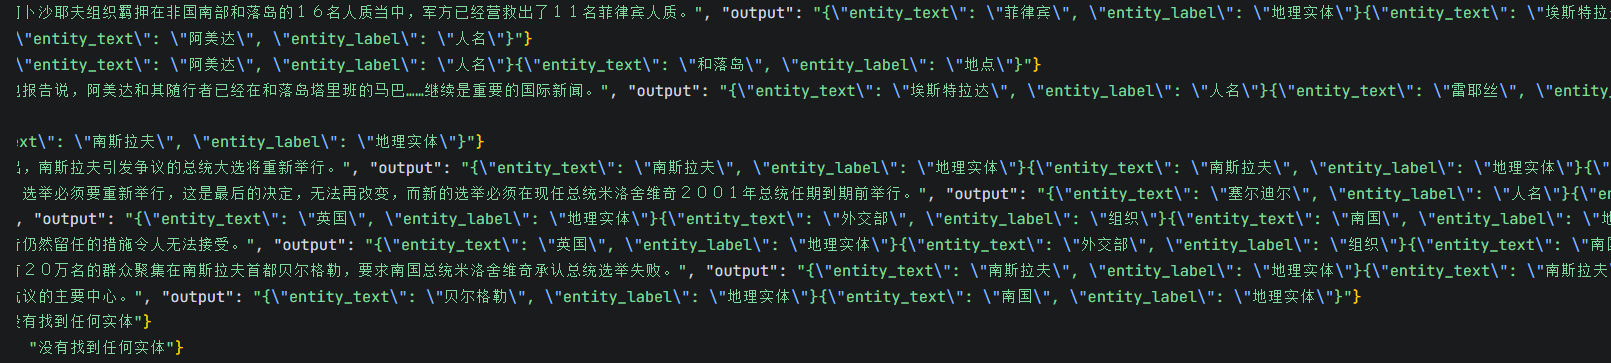

In [8]:
#抽取个1000条作为负面样本
ne_df = ne_df.sample(n=1000, random_state=42)
print(ne_df.head())

                                             instruction  \
9993   你是一个文本实体识别领域的专家，你需要从给定的句子中提取 地点; 人名; 地理实体; 组织 ...   
15347  你是一个文本实体识别领域的专家，你需要从给定的句子中提取 地点; 人名; 地理实体; 组织 ...   
5278   你是一个文本实体识别领域的专家，你需要从给定的句子中提取 地点; 人名; 地理实体; 组织 ...   
9401   你是一个文本实体识别领域的专家，你需要从给定的句子中提取 地点; 人名; 地理实体; 组织 ...   
88     你是一个文本实体识别领域的专家，你需要从给定的句子中提取 地点; 人名; 地理实体; 组织 ...   

                                                   input  \
9993   文本:所幸目前陈姓女学生已经没有生命危险，她的分手男友今天回学校参加毕业典礼，而陈姓女学生也...   
15347           文本:为什么我们非要用我们城里人的幸福观，我们城里人的现代化的标准去要求他们呢？   
5278                  文本:因此我们正在％ｐｗ，呃，教人们如何成为％ｐｗ在卢旺达自食其力．   
9401   文本:“这个功力同样这么高，那你就爬３６层，如果再高一点就７２层，那么现在这个是最高的，就１０７。   
88                  文本:可是从９号马可被送回莫斯科一事看起来，中共很可能会放弃米洛舍维奇。   

                                                  output  
9993                                            没有找到任何实体  
15347                                           没有找到任何实体  
5278        {"entity_text": "卢旺达", "entity_label": "地点"}  
9401                                      

In [9]:
train_df=pd.concat([train_df,ne_df],axis=0)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)#打乱
print(f"train_df size: {len(train_df)}")


train_df size: 6259


# 02加载模型和分词器并进行数据的标准化和预处理

### 量化配置

In [10]:
import torch
#from transformers import BitsAndBytesConfig
#bnb_config = BitsAndBytesConfig(
#    load_in_4bit=True,
#    bnb_4bit_use_double_quant=True,     # 双重量化，进一步省显存
#    bnb_4bit_quant_type="bp4",         
#    bnb_4bit_compute_dtype=torch.bfloat16)

In [11]:
from modelscope import snapshot_download, AutoTokenizer
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForSeq2Seq
import torch
import os

model_id = "qwen/Qwen2-0.5B-Instruct"    
model_dir = "./qwen/Qwen2-0.5B-Instruct"

# 在modelscope上下载Qwen模型到本地目录下
if not os.path.exists(model_dir):
    model_dir = snapshot_download(model_id, cache_dir="./", revision="master")
device = "cuda" if torch.cuda.is_available() else "cpu"
# Transformers加载模型权重
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_dir, device_map=device, torch_dtype=torch.bfloat16)
#quantization_config=bnb_config)
model.enable_input_require_grads()  # 开启梯度检查点时，要执行该方法

2026-05-08 18:52:45,800 - modelscope - INFO - PyTorch version 2.1.2+cu121 Found.
2026-05-08 18:52:45,801 - modelscope - INFO - Loading ast index from /root/.cache/modelscope/ast_indexer
2026-05-08 18:52:45,826 - modelscope - INFO - Loading done! Current index file version is 1.11.0, with md5 027fb7118fd3c0039716c440f14de05f and a total number of 953 components indexed
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [12]:
def process_func(example):
    """
    将数据集进行标准化处理, 处理成模型可以接受的template格式
    """

    MAX_LENGTH = 512 
    input_ids, attention_mask, labels = [], [], []
    #标准化序列化template
    system_prompt = """你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. 以 json 格式输出, 如 {"entity_text": "当归", "entity_label": "中药"} 注意: 1. 输出的每一行都必须是正确的 json 字符串. 2. 找不到任何实体时, 输出"没有找到任何实体". """
    
    instruction = tokenizer(
        f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n{example['input']}<|im_end|>\n<|im_start|>assistant\n",
        add_special_tokens=False,
    )
    response = tokenizer(f"{example['output']}", add_special_tokens=False)
    input_ids = instruction["input_ids"] + response["input_ids"] + [tokenizer.pad_token_id]
    attention_mask = (
        instruction["attention_mask"] + response["attention_mask"] + [1]
    )
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"] + [tokenizer.pad_token_id]
    if len(input_ids) > MAX_LENGTH:  # 做一个截断
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}   

In [13]:
from datasets import Dataset
#将pandas DataFrame转换为datasets Dataset，方便后续处理
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)
dev_ds = Dataset.from_pandas(dev_df)
train_dataset = train_ds.map(process_func, remove_columns=train_ds.column_names)
test_dataset = test_ds.map(process_func, remove_columns=test_ds.column_names)
dev_dataset = dev_ds.map(process_func, remove_columns=dev_ds.column_names)


Map:   0%|          | 0/6259 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/657 [00:00<?, ? examples/s]

# 03开训！
- 量化 fp4 bit这个包没搞定，先不qlora了
- lora8 32 0.1

In [14]:
from peft import LoraConfig, TaskType, get_peft_model

config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
    ],
    inference_mode=False,  # 训练模式
    r=4,  # Lora 秩
    lora_alpha=16,  
    lora_dropout=0.1,  # Dropout 比例
)

model = get_peft_model(model, config)

In [26]:
import re
import numpy as np
from collections import defaultdict
import re
import numpy as np
from collections import defaultdict

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    if isinstance(logits, tuple):
        logits = logits[0]
    
    # 1. 强制转为 numpy 并确保是整数类型
    preds = np.array(logits)
    labels = np.array(labels)
    
    # 2. 安全清理：获取词表大小，防止非法索引
    vocab_size = tokenizer.vocab_size
    
    # 清理预测值：剔除负数，剔除超出词表的 ID
    preds = np.where((preds >= 0) & (preds < vocab_size), preds, tokenizer.pad_token_id)
    preds = preds.astype(np.int64) # 显式转为 int64
    
    # 清理标签值：将 -100 替换为 pad_token_id，并防止溢出
    labels = np.where((labels >= 0) & (labels < vocab_size), labels, tokenizer.pad_token_id)
    labels = labels.astype(np.int64)

    # 3. 解码（添加错误处理）
    try:
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    except Exception as e:
        print(f"Decoding Error: {e}")
        # 如果还是错，返回空指标，防止训练中断
        return {"error_in_decoding": 1.0}

    # 4. 打印调试（这一步能帮你看到模型到底吐了什么）
 #   if len(decoded_preds) > 0:
  #      print(f"\n[Debug] Pred: {decoded_preds[0][:100]}...") # 只打印前100字
   #     print(f"[Debug] Label: {decoded_labels[0][:100]}...")

    # 5. 正则提取逻辑 (针对你的 JSON 拼接格式)
    combined_pattern = re.compile(r'\"entity_text\"\s*:\s*\"(.*?)\".*?\"entity_(?:label|type)\"\s*:\s*\"(.*?)\"')
    match_names = ['方剂', '中医诊断', '中医证候', '其他治疗', '中医治疗', '中药', '西医治疗', '西医诊断', '临床表现', '中医治则']
    class_stats = {name: {"tp": 0, "fp": 0, "fn": 0} for name in match_names}

    for p_text, l_text in zip(decoded_preds, decoded_labels):
        p_ents = set(combined_pattern.findall(p_text))
        l_ents = set(combined_pattern.findall(l_text))

        for name in match_names:
            p_sub = {e[0] for e in p_ents if e[1] == name}
            l_sub = {e[0] for e in l_ents if e[1] == name}
            class_stats[name]["tp"] += len(p_sub & l_sub)
            class_stats[name]["fp"] += len(p_sub - l_sub)
            class_stats[name]["fn"] += len(l_sub - p_sub)

    # 6. 指标汇总
    results = {}
    total_tp, total_fp, total_fn = 0, 0, 0
    for name in match_names:
        stats = class_stats[name]
        p = stats["tp"] / (stats["tp"] + stats["fp"] + 1e-10)
        r = stats["tp"] / (stats["tp"] + stats["fn"] + 1e-10)
        results[f"{name}_f1"] = 2 * p * r / (p + r + 1e-10)
        total_tp += stats["tp"]
        total_fp += stats["fp"]
        total_fn += stats["fn"]

    final_p = total_tp / (total_tp + total_fp + 1e-10)
    final_r = total_tp / (total_tp + total_fn + 1e-10)
    results["f1"] = 2 * final_p * final_r / (final_p + final_r + 1e-10)
    results["precision"] = final_p
    results["recall"] = final_r
    
    return results

In [23]:
model.print_trainable_parameters()

trainable params: 368,640 || all params: 494,401,408 || trainable%: 0.07456289444871483


In [17]:
from swanlab.integration.transformers import SwanLabCallback
import swanlab
swanlab.init()
swanlab_callback = SwanLabCallback(
    project="中医药Qwen2.5 0.5b-NER-fintune",
    experiment_name="小模型先试试",
    description="使用通义千问Qwen2.5小模型在中医药NER数据集上微调，实现关键实体识别任务。",
    config={
        "model": model_id,
        "model_dir": model_dir,
        "dataset": "中医药NER",
        "metrics": compute_metrics,
    },
)

Output()

Output()

swanlab: Tracking run with swanlab version 0.7.17

swanlab: Run data will be saved locally in /root/autodl-tmp/swanlog/run-20260508_185307-8r6rptsz7ft3646uw6l1f

swanlab: 👋 Hi duan_daniel,welcome to swanlab!

swanlab: Syncing run horse-8 to the cloud

swanlab: 🏠 View project at https://swanlab.cn/@duan_daniel/autodl-tmp

swanlab: 🚀 View run at https://swanlab.cn/@duan_daniel/autodl-tmp/runs/8r6rptsz7ft3646uw6l1f

In [18]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

# 1. 配置 Seq2Seq 训练参数
args = Seq2SeqTrainingArguments(
    output_dir="./output/Qwen2.5-NER-Fixed",
    
    # 策略方案
    evaluation_strategy="steps",
    eval_steps=100,               # 建议不要太频繁，给显存喘息机会
    save_steps=500,
    logging_steps=10,
    
    # 显存优化关键组合
    predict_with_generate=True,    # 开启生成模式，eval_preds 将只包含 Token ID
    generation_max_length=1024,     # 限制生成长度，防止模型评估时“胡言乱语”导致卡死
    eval_accumulation_steps=1,     # 每步评估结果直接传回 CPU，显存占用恒定
    
    # 训练超参数
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,  # 开启 predict_with_generate 后，这里可以放心设为 4
    gradient_accumulation_steps=4,
    learning_rate=1e-4,            # LoRA 建议值
    num_train_epochs=2,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    
    # 精度与稳定性
    bf16=True, 
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False}, # 消除之前的警告
    
    # 外部工具
    report_to="none",              # 避免与手动 callback 冲突
    save_total_limit=2,
)

In [27]:
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    # DataCollatorForSeq2Seq 会自动处理 Padding，非常适合生成任务
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
    compute_metrics=compute_metrics, # 使用我刚才帮你优化的那个版本
    callbacks=[swanlab_callback],
)

In [28]:
# 训练前手动清理一下残留显存
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [29]:
trainer.train()

Step,Training Loss,Validation Loss,方剂 F1,中医诊断 F1,中医证候 F1,其他治疗 F1,中医治疗 F1,中药 F1,西医治疗 F1,西医诊断 F1,临床表现 F1,中医治则 F1,F1,Precision,Recall
100,0.151500,0.178704,0.812500,1.000000,0.758621,0.571429,0.871795,0.260355,0.727273,0.894118,0.803922,0.923077,0.654275,0.486188,1.000000
200,0.137900,0.147491,0.928571,0.392857,0.846154,0.571429,0.809524,0.271605,0.727273,0.716981,0.921348,0.750000,0.618629,0.447837,1.000000
300,0.130900,0.147298,0.896552,0.846154,0.745763,0.800000,0.894737,0.293333,0.888889,0.710280,0.881720,0.521739,0.653061,0.484848,1.000000
400,0.113600,0.140505,0.896552,0.628571,0.745763,0.666667,0.944444,0.261905,0.888889,0.737864,0.891304,0.571429,0.630824,0.460733,1.000000
500,0.123900,0.134612,0.896552,0.372881,0.709677,0.500000,0.829268,0.291391,0.888889,0.853933,0.780952,0.461538,0.607945,0.436725,1.000000
600,0.102400,0.133681,0.812500,0.733333,0.619718,0.400000,0.918919,0.291391,0.727273,0.835165,0.911111,0.333333,0.629696,0.459530,1.000000
700,0.129600,0.134187,0.742857,0.785714,0.647059,0.333333,0.829268,0.301370,0.666667,0.817204,0.964706,0.800000,0.657944,0.490251,1.000000


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le


[Debug] Pred: system
你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. ...
[Debug] Label: {"entity_text": "黄疸", "entity_label": "中医诊断"}...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le


[Debug] Pred: system
你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. ...
[Debug] Label: {"entity_text": "黄疸", "entity_label": "中医诊断"}...


...

/root/miniconda3/lib/python3.10/site-packages/peft/utils/save_and_load.py:154: UserWarning: Could not find a config file in ./qwen/Qwen2-0.5B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct g


[Debug] Pred: system
你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. ...
[Debug] Label: {"entity_text": "黄疸", "entity_label": "中医诊断"}...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le


[Debug] Pred: system
你是一个中医药领域文本实体识别的专家，你需要从给定的句子中提取：方剂, 中医诊断, 中医证候, 其他治疗, 中医治疗, 中药, 西医治疗, 西医诊断, 临床表现, 中医治则 这些实体. ...
[Debug] Label: {"entity_text": "黄疸", "entity_label": "中医诊断"}...


TrainOutput(global_step=782, training_loss=0.13567617169731414, metrics={'train_runtime': 1573.1483, 'train_samples_per_second': 7.957, 'train_steps_per_second': 0.497, 'total_flos': 6868771137629952.0, 'train_loss': 0.13567617169731414, 'epoch': 1.9987220447284346})

In [ ]:
swanlab.finish()